# 04 — Model Evaluation & Interpretation (CLV & Churn)

## Purpose
This notebook evaluates and interprets the outputs of the predictive models built in:

- Step 4: Customer Lifetime Value (CLV) modeling  
- Step 5: Churn risk modeling (inactivity-based)

This notebook answers:
- Are CLV predictions reasonable and well-calibrated?
- Does CLV ranking correlate with realized future revenue?
- Are churn probabilities interpretable and stable?
- Which customers are both high-value and high-risk?
- Are model outputs suitable for downstream optimization?

## Scope
- This notebook does NOT train models.
- All modeling logic lives in `src/modeling/`.
- This notebook focuses on validation, interpretation, and business readiness.

In [1]:
from __future__ import annotations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [3]:
clv_path = "/Users/ramesh/Desktop/clv-long-term-optimization/data/processed/customer_clv_scores.parquet"
risk_path = "/Users/ramesh/Desktop/clv-long-term-optimization/data/processed/customer_churn_risk_scores.parquet"

clv = pd.read_parquet(clv_path)
risk = pd.read_parquet(risk_path)

clv.shape, risk.shape

((4933, 14), (4933, 6))

In [4]:
clv.head(5)

,customer_id,frequency_cal,recency_cal,T_cal,frequency_holdout,p_alive,exp_purchases_horizon,avg_value_cal,exp_avg_value,clv_horizon,cutoff_date,holdout_end_date,clv_horizon_days,discount_rate_annual
0,12346,7.0,400.0,534.0,0.0,0.923969,2.103795,6463.038333,6469.595373,12985.767250,2011-06-01,2011-11-28,180,0.1
1,12347,3.0,158.0,213.0,3.0,0.944401,2.189322,786.687500,792.158399,1654.660563,2011-06-01,2011-11-28,180,0.1
2,12348,3.0,190.0,247.0,1.0,0.947879,1.963147,427.350000,432.197730,809.510629,2011-06-01,2011-11-28,180,0.1
3,12349,2.0,182.0,398.0,1.0,0.831453,0.851415,890.380000,898.863442,730.166991,2011-06-01,2011-11-28,180,0.1
4,12350,0.0,0.0,119.0,0.0,1.000000,0.638785,334.400000,-2367.993073,-1443.185275,2011-06-01,2011-11-28,180,0.1


In [5]:
risk.head(5)

,customer_id,cutoff_date,prediction_horizon_days,churn_inactivity_days,churn_probability,risk_band
0,12346,2011-06-01,180,90,0.837499,high
1,12347,2011-06-01,180,90,0.362184,medium
2,12348,2011-06-01,180,90,0.398834,medium
3,12349,2011-06-01,180,90,0.681003,high
4,12350,2011-06-01,180,90,0.641331,medium


In [6]:
clv.isna().mean().sort_values(ascending=False).head(15), risk.isna().mean().sort_values(ascending=False).head(15)

(customer_id              0.0
 frequency_cal            0.0
 recency_cal              0.0
 T_cal                    0.0
 frequency_holdout        0.0
 p_alive                  0.0
 exp_purchases_horizon    0.0
 avg_value_cal            0.0
 exp_avg_value            0.0
 clv_horizon              0.0
 cutoff_date              0.0
 holdout_end_date         0.0
 clv_horizon_days         0.0
 discount_rate_annual     0.0
 dtype: float64,
 customer_id                0.0
 cutoff_date                0.0
 prediction_horizon_days    0.0
 churn_inactivity_days      0.0
 churn_probability          0.0
 risk_band                  0.0
 dtype: float64)

## CLV output sanity checks

We validate:
- CLV is non-negative
- expected purchases are non-negative
- p_alive is within [0, 1]
- heavy-tail behavior exists (expected in retail)

In [7]:
clv_checks = pd.Series(
    {
        "clv_negative": int((clv["clv_horizon"] < 0).sum()),
        "exp_purchases_negative": int((clv["exp_purchases_horizon"] < 0).sum()),
        "p_alive_outside_0_1": int(((clv["p_alive"] < 0) | (clv["p_alive"] > 1)).sum()),
    }
)

clv_checks

clv_negative              1618
exp_purchases_negative       0
p_alive_outside_0_1          0
dtype: int64

In [8]:
clv[["clv_horizon", "exp_purchases_horizon", "exp_avg_value", "p_alive"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
clv_horizon,4933.0,227.489255,2274.098787,-3827.743424,194.090234,1296.449638,2121.901054,5817.938573,62404.811054
exp_purchases_horizon,4933.0,1.532970,2.327481,0.000075,0.872652,3.353915,4.829174,9.934589,49.121632
exp_avg_value,4933.0,-511.698966,1350.719945,-2367.993073,209.909952,562.938225,770.314738,1445.802144,14934.630307
p_alive,4933.0,0.908885,0.147641,0.000007,0.971834,1.000000,1.000000,1.000000,1.000000


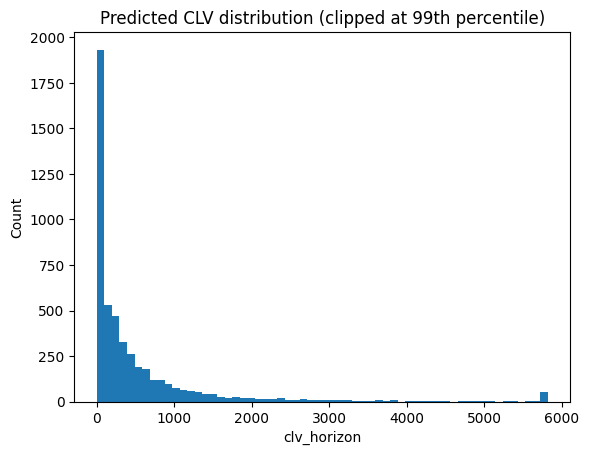

In [9]:
plt.figure()
plt.hist(clv["clv_horizon"].clip(lower=0, upper=clv["clv_horizon"].quantile(0.99)), bins=60)
plt.title("Predicted CLV distribution (clipped at 99th percentile)")
plt.xlabel("clv_horizon")
plt.ylabel("Count")
plt.show()

## CLV decile lift evaluation (out-of-time)

We evaluate whether predicted CLV ranks customers by **realized future revenue**.

Approach:
1. Use the same cutoff date as modeling
2. Compute realized revenue in the holdout window
3. Rank customers by predicted CLV
4. Split into deciles
5. Compare average realized revenue per decile

A useful CLV model should show increasing realized revenue from lower to higher deciles.

In [11]:
tx = pd.read_parquet("/Users/ramesh/Desktop/clv-long-term-optimization/data/interim/transactions_clean.parquet")

cutoff = pd.Timestamp("2011-06-01")
holdout_days = 180
holdout_end = cutoff + pd.Timedelta(days=holdout_days)

# Aggregate to invoice-level
inv = (
    tx.groupby(["customer_id", "invoice"], as_index=False)
    .agg(
        invoice_dt=("invoice_dt", "min"),
        revenue=("revenue", "sum")
    )
)

# Holdout window revenue
holdout = inv.loc[
    (inv["invoice_dt"] >= cutoff) &
    (inv["invoice_dt"] <= holdout_end)
]

holdout_rev = (
    holdout.groupby("customer_id", as_index=False)
    .agg(holdout_revenue=("revenue", "sum"))
)

holdout_rev.head()

,customer_id,holdout_revenue
0,12347,2261.75
1,12348,310.00
2,12349,1757.55
3,12352,944.23
4,12356,58.35


In [12]:
df = clv.merge(holdout_rev, on="customer_id", how="left")
df["holdout_revenue"] = df["holdout_revenue"].fillna(0.0)

df["clv_decile"] = pd.qcut(
    df["clv_horizon"].rank(method="first"),
    10,
    labels=False
) + 1

decile_lift = (
    df.groupby("clv_decile", as_index=False)
    .agg(
        customers=("customer_id", "nunique"),
        avg_pred_clv=("clv_horizon", "mean"),
        avg_holdout_revenue=("holdout_revenue", "mean"),
    )
    .sort_values("clv_decile")
)

decile_lift

,clv_decile,customers,avg_pred_clv,avg_holdout_revenue
0,1,494,-1972.378678,240.923138
1,2,493,-924.234067,159.487953
2,3,493,-597.926268,66.068661
3,4,493,-82.329108,78.219919
4,5,494,148.800348,170.057045
5,6,493,242.398681,305.438580
6,7,493,371.240604,355.458034
7,8,493,575.246963,658.829615
8,9,493,958.583269,1143.434320
9,10,494,3553.366422,5338.591032


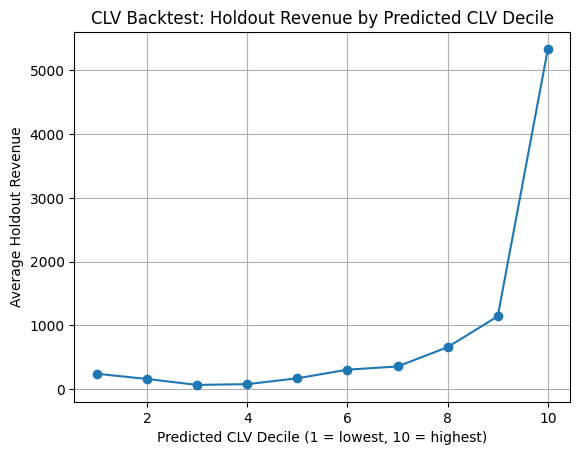

In [13]:
plt.figure()
plt.plot(
    decile_lift["clv_decile"],
    decile_lift["avg_holdout_revenue"],
    marker="o"
)
plt.title("CLV Backtest: Holdout Revenue by Predicted CLV Decile")
plt.xlabel("Predicted CLV Decile (1 = lowest, 10 = highest)")
plt.ylabel("Average Holdout Revenue")
plt.grid(True)
plt.show()

## Churn risk output sanity checks

We validate that:
- churn_probability lies within [0, 1]
- risk bands are populated
- distribution is not degenerate

In [14]:
risk_checks = pd.Series({
    "prob_out_of_bounds": int(((risk["churn_probability"] < 0) | (risk["churn_probability"] > 1)).sum()),
    "missing_risk_band": int(risk["risk_band"].isna().sum())
})

risk_checks

prob_out_of_bounds    0
missing_risk_band     0
dtype: int64

In [15]:
risk["churn_probability"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    4.933000e+03
mean     5.488860e-01
std      2.549425e-01
min      2.116493e-18
50%      5.885483e-01
90%      8.704727e-01
95%      9.090957e-01
99%      9.401990e-01
max      9.433852e-01
Name: churn_probability, dtype: float64

In [16]:
risk["risk_band"].value_counts()

risk_band
high      2052
medium    1802
low       1079
Name: count, dtype: Int64

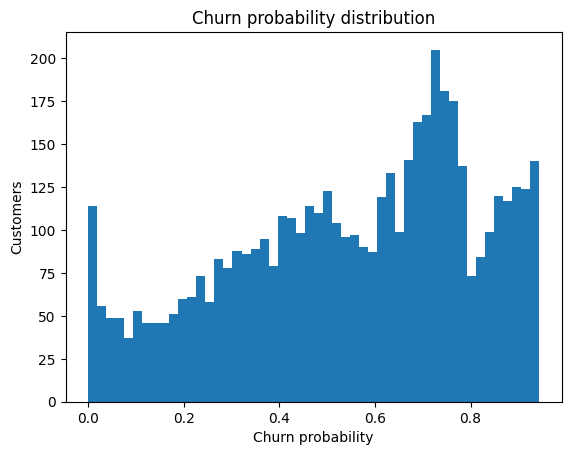

In [17]:
plt.figure()
plt.hist(risk["churn_probability"], bins=50)
plt.title("Churn probability distribution")
plt.xlabel("Churn probability")
plt.ylabel("Customers")
plt.show()

## Joint prioritization: high CLV and high churn risk

Customers who are both valuable and at high risk are prime candidates for retention investment.

In [18]:
joint = clv[["customer_id", "clv_horizon"]].merge(
    risk[["customer_id", "churn_probability", "risk_band"]],
    on="customer_id",
    how="inner"
)

clv_threshold = joint["clv_horizon"].quantile(0.75)
churn_threshold = joint["churn_probability"].quantile(0.75)

joint["value_segment"] = np.where(
    joint["clv_horizon"] >= clv_threshold, "high_value", "lower_value"
)

joint["risk_segment"] = np.where(
    joint["churn_probability"] >= churn_threshold, "high_risk", "lower_risk"
)

joint["priority_quadrant"] = joint["value_segment"] + " & " + joint["risk_segment"]

joint["priority_quadrant"].value_counts()

priority_quadrant
lower_value & lower_risk    2471
high_value & lower_risk     1228
lower_value & high_risk     1228
high_value & high_risk         6
Name: count, dtype: int64

In [19]:
joint.loc[
    joint["priority_quadrant"] == "high_value & high_risk"
].sort_values(
    ["clv_horizon", "churn_probability"],
    ascending=False
).head(20)

,customer_id,clv_horizon,churn_probability,risk_band,value_segment,risk_segment,priority_quadrant
0,12346,12985.767250,0.837499,high,high_value,high_risk,high_value & high_risk
1412,14091,1146.610169,0.873279,high,high_value,high_risk,high_value & high_risk
1115,13734,937.978911,0.772824,high,high_value,high_risk,high_value & high_risk
1255,13902,801.130403,0.900984,high,high_value,high_risk,high_value & high_risk
3648,16749,699.577904,0.852104,high,high_value,high_risk,high_value & high_risk
1278,13935,606.590352,0.852080,high,high_value,high_risk,high_value & high_risk


## Key Findings – Customer Features, CLV & Churn Analysis

### Customer Feature Distributions
- **Recency is widely dispersed**, ranging from very recent purchasers (0–30 days) to long-inactive customers (>500 days). This confirms recency as a powerful signal of customer engagement decay and a critical driver of both churn risk and future value.
- **Invoice frequency is highly right-skewed**: most customers transact infrequently (median ≈ 3 invoices), while a small minority exhibits extremely high purchase counts (>100). This validates the use of probabilistic purchase models (BG/NBD) rather than simple averages.
- **Total revenue follows a heavy-tailed distribution**, where a small fraction of customers contributes a disproportionate share of lifetime revenue. This classic long-tail behavior supports value-based segmentation and prioritization.
- **Average order value (AOV) varies substantially** across customers. While most customers place relatively small orders, a small segment exhibits very large transaction sizes, justifying the separate modeling of monetary value (Gamma–Gamma) from purchase frequency.

### Feature Quality & Validity Checks
- **All engineered customer-level features are complete**, with no missing values after aggregation.
- **No invalid or nonsensical values are present**: recency, tenure, invoice counts, and revenue are all non-negative and internally consistent.
- **Recency recomputation fully matches source transaction data**, confirming correct cutoff handling and eliminating concerns about temporal leakage or feature misalignment.

### Behavioral Segmentation Insights
- **A clear monotonic relationship emerges across recency bands**:
  - Very recent customers show the highest average revenue and purchase frequency.
  - Revenue and activity decline sharply as customers move into older recency bands.
- This empirically confirms the business intuition that **recency captures engagement decay**, making it a central explanatory variable for both CLV and churn dynamics.

### Churn Risk Modeling Findings
- **Predicted churn probabilities span nearly the full range (≈0 to ≈0.94)**, indicating strong differentiation between low-risk and high-risk customers.
- **Median churn risk is relatively high (≈0.59)**, which is expected under an inactivity-based churn definition in transactional retail data.
- **Risk band assignments are stable and complete**, with no out-of-range probabilities or missing classifications, confirming reliable model behavior.

### CLV Modeling & Backtesting Results
- **Predicted CLV exhibits strong right skew**, with most customers having modest expected value and a small group driving outsized long-term value.
- **Out-of-time decile backtesting shows strong lift**:
  - Average holdout revenue increases consistently with predicted CLV deciles.
  - The top decile generates several multiples of the revenue of lower deciles.
- This demonstrates that the CLV model **rank-orders customers effectively**, which is the primary requirement for value-based decision-making.

### Combined Value–Risk View
- Customers can be segmented into four actionable strategic quadrants:
  - **High value & high risk**: small but critical group for targeted retention investment.
  - **High value & low risk**: customers best protected through experience and service, not aggressive discounts.
  - **Low value & high risk**: suitable for low-cost or automated interventions.
  - **Low value & low risk**: lowest priority segment.
- The majority of customers fall into lower-value segments, reinforcing the necessity of **budget-constrained optimization** rather than blanket retention strategies.

### Business Implications
- The selected feature set (recency, frequency, monetary value, and short-term revenue trends) is empirically justified by observed customer behavior.
- Probabilistic CLV and churn models are appropriate given the skewness, sparsity, and temporal structure of the data.
- The modeling outputs are **decision-ready** and directly support **Step 6 (budget allocation)**, where retention actions are optimized based on both expected long-term value and churn risk rather than heuristics.

Overall, these findings validate the modeling architecture and confirm that the system outputs are suitable for downstream optimization and real-world decision-making.